In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize

sns.set(context='talk')

### helpers

In [3]:
def set_seed(seed: int):
    # Reproducibility for python/numpy/torch RNGs
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_trials(n_stim=20, boundaries=(0.25, 0.5, 0.75)):
    """
    Build full factorial trial table following the actual task design.

    b=0.50 : uniform sampling across (0, 1)                    — 5 stims per quartile
    b=0.25 : 5 unique stims in (0, 0.25) each duplicated ×2   — compressed below boundary
             + 10 unique stims in (0.25, 0.75)                — no stims > 0.75
    b=0.75 : mirror of b=0.25

    Each boundary yields exactly 10 class-0 and 10 class-1 trials by construction.

    Columns
    -------
    stim_idx        : row-level rank within boundary (0-19).
    unique_stim_idx : identity-level rank; duplicate pairs share the same index.
    """
    n_half = n_stim // 4   # stims per quartile = 5

    rows = []
    for b in boundaries:
        if b == 0.50:
            stim_values = np.linspace(0, 1, n_stim + 2, dtype=np.float32)[1:-1]   # 20 uniform
            unique_ids  = list(range(n_stim))

        elif b == 0.25:
            compressed  = np.linspace(0, 0.25, n_half + 2, dtype=np.float32)[1:-1]          # 5 unique
            expanded    = np.linspace(0.25, 0.75, n_stim // 2 + 2, dtype=np.float32)[1:-1]  # 10 unique
            stim_values = np.concatenate([np.repeat(compressed, 2), expanded])               # 10 + 10
            unique_ids  = (
                [i for i in range(n_half) for _ in range(2)]          # 0,0,1,1,...,4,4
                + list(range(n_half, n_half + n_stim // 2))           # 5..14
            )

        elif b == 0.75:
            expanded    = np.linspace(0.25, 0.75, n_stim // 2 + 2, dtype=np.float32)[1:-1]  # 10 unique
            compressed  = np.linspace(0.75, 1.0,  n_half + 2, dtype=np.float32)[1:-1]       # 5 unique
            stim_values = np.concatenate([expanded, np.repeat(compressed, 2)])               # 10 + 10
            unique_ids  = (
                list(range(n_stim // 2))                                                     # 0..9
                + [n_stim // 2 + i for i in range(n_half) for _ in range(2)]                # 10,10,...,14,14
            )

        for i, (stim, uid) in enumerate(zip(stim_values, unique_ids)):
            cls = float(stim >= b)
            rows.append({
                'boundary':        float(b),
                'boundary_label':  f'b={b:.2f}',
                'stim':            float(stim),
                'stim_idx':        int(i),
                'unique_stim_idx': int(uid),
                'class':           cls,
            })

    return pd.DataFrame(rows)


def split_train_test(df, test_frac=0.2, seed=1):
    """
    Deterministic train/test split that keeps duplicate stim pairs together.

    Stratifies by boundary first (guaranteeing each condition contributes test
    samples), then groups rows by unique_stim_idx so that both copies of a
    duplicated stimulus always land in the same split half — preventing leakage.
    """
    rng = np.random.default_rng(seed)
    test_idx = []

    for _, b_grp in df.groupby('boundary'):
        # One group = all rows sharing a unique_stim_idx within this boundary.
        # Duplicated stims have 2 rows; unique stims have 1 row.
        groups = [g.index.to_numpy() for _, g in b_grp.groupby('unique_stim_idx')]
        rng.shuffle(groups)

        # At least 1 group from each boundary goes to test.
        n_test_groups = max(1, int(round(len(groups) * test_frac)))
        for grp_rows in groups[:n_test_groups]:
            test_idx.extend(grp_rows)

    test_idx  = np.array(sorted(test_idx))
    train_idx = df.index.difference(test_idx)

    return (
        df.loc[train_idx].reset_index(drop=True),
        df.loc[test_idx].reset_index(drop=True),
    )


def df_to_tensors(df):
    # Convert dataframe columns into model input/target tensors
    X = torch.tensor(df[['stim', 'boundary']].values, dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values, dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values, dtype=torch.float32)
    y_bound = torch.tensor(df[['boundary']].values, dtype=torch.float32)
    return X, y_class, y_stim, y_bound


In [4]:
# config
n_stim = 20
boundaries = (0.25, 0.5, 0.75)
n_nets = 30

# ── Loss weights ──────────────────────────────────────────────────────────────
stim_mse_wt  = 2.0  # MSE toward raw stimulus value — applied to ALL trials
exp_bound_wt = 2.   # MSE toward boundary — applied to expanded-class trials only

use_train_test_split = True
test_frac = 0.20
base_seed = 2026030

# generate 60 unique trials
trials_df = make_trials(n_stim=n_stim, boundaries=boundaries)
assert len(trials_df) == 60

# each boundary must have exactly n_stim/2 trials per class (balanced by construction)
for b, grp in trials_df.groupby('boundary'):
    assert int(grp['class'].sum()) == n_stim // 2, f'Class imbalance at boundary={b}'

if use_train_test_split:
    train_df, test_df = split_train_test(trials_df, test_frac=test_frac, seed=base_seed)
else:
    train_df = trials_df.copy()
    test_df = trials_df.copy()

print(f'Total trials: {len(trials_df)} | Train: {len(train_df)} | Test: {len(test_df)}')

trials_df.head()


Total trials: 60 | Train: 48 | Test: 12


,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class
0,0.25,b=0.25,0.041667,0,0,0.0
1,0.25,b=0.25,0.041667,1,0,0.0
2,0.25,b=0.25,0.083333,2,1,0.0
3,0.25,b=0.25,0.083333,3,1,0.0
4,0.25,b=0.25,0.125000,4,2,0.0


In [5]:
# convert to tensors
X_train, y_class_train, y_stim_train, y_bound_train = df_to_tensors(train_df)
X_test, y_class_test, y_stim_test, y_bound_test = df_to_tensors(test_df)
X_full, y_class_full, y_stim_full, y_bound_full = df_to_tensors(trials_df)

# data loaders
batch_size = 48
train_ds = TensorDataset(X_train, y_class_train, y_stim_train, y_bound_train)
test_ds = TensorDataset(X_test, y_class_test, y_stim_test, y_bound_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

train_loader, test_loader


(<torch.utils.data.dataloader.DataLoader at 0x7f5d5e64dd50>,
 <torch.utils.data.dataloader.DataLoader at 0x7f5d5f3ddd10>)

In [6]:
# ── Architecture ──────────────────────────────────────────────────────────────
class BoundaryNet(nn.Module):
    """
    2-input → 10-unit hidden → 1-output boundary-classification network.

    Inputs : [stim ∈ (0,1),  boundary ∈ {0.25, 0.50, 0.75}]
    Hidden : 10 units, ReLU
    Output : sigmoid  →  response ∈ (0,1)
    """
    def __init__(self, in_dim: int = 2, hidden_dim: int = 10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(h))

    def forward_with_hidden(self, x: torch.Tensor):
        """Return (output, hidden_activations) for neural analysis."""
        h = F.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out, h


# ── Training / evaluation epoch ───────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None):
    """
    Run one full pass over *loader*.

    Loss components:
      stim_mse_wt  · MSE(pred, y_stim)                  ← track raw stimulus, all trials
      exp_bound_wt · MSE(pred[exp], boundary[exp])       ← pull expanded class toward boundary

    Returns
    -------
    dict: total, loss_stim, loss_exp_bound, acc, corr
    """
    training = optimizer is not None
    model.train(training)
    ctx = torch.enable_grad() if training else torch.no_grad()

    totals = dict(total=0.0, loss_stim=0.0, loss_exp_bound=0.0, correct=0, n=0)
    pred_list, stim_list = [], []

    with ctx:
        for X, y_class_b, y_stim_b, y_bound_b in loader:
            pred = model(X)
            pred_list.append(pred.detach())
            stim_list.append(y_stim_b)

            # ── Compressed-class mask ──────────────────────────────────────────
            is_comp = (
                ((y_class_b == 0) & (y_bound_b < 0.5)) |
                ((y_class_b == 1) & (y_bound_b > 0.5))
            ).squeeze(1)
            is_exp = ~is_comp

            # ── Loss 1: Stimulus MSE — all trials ─────────────────────────────
            stim_loss = F.mse_loss(pred, y_stim_b) * stim_mse_wt

            # ── Loss 2: Boundary pull — expanded-class trials only ─────────────
            if is_exp.any():
                exp_bound_loss = F.mse_loss(pred[is_exp], y_bound_b[is_exp]) * exp_bound_wt
            else:
                exp_bound_loss = torch.tensor(0.0)

            loss = stim_loss + exp_bound_loss

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_n = X.size(0)
            totals['total']          += loss.item()           * batch_n
            totals['loss_stim']      += stim_loss.item()      * batch_n
            totals['loss_exp_bound'] += exp_bound_loss.item() * batch_n
            y_bound_thresh = X[:, 1:2]
            totals['correct'] += ((pred >= y_bound_thresh).float() == y_class_b).sum().item()
            totals['n']       += batch_n

    all_pred = torch.cat(pred_list).squeeze()
    all_stim = torch.cat(stim_list).squeeze()
    corr = torch.corrcoef(torch.stack([all_pred, all_stim]))[0, 1].item()

    n       = max(totals.pop('n'), 1)
    correct = totals.pop('correct')
    return {k: v / n for k, v in totals.items()} | {'acc': correct / n, 'corr': corr}


# ── Full-dataset inference with hidden activations ────────────────────────────
def evaluate_model_on_df(model, df):
    """
    Run inference on every row of *df* in one shot (no shuffling).

    Returns
    -------
    pred_df : copy of df with 'resp' and 'class_pred' columns added
    hidden  : np.ndarray  [n_trials, hidden_dim]
    metrics : dict
    """
    model.eval()
    X, y_class, y_stim, y_bound = df_to_tensors(df)

    with torch.no_grad():
        out, h = model.forward_with_hidden(X)

    resp   = out.squeeze(1).numpy()
    hidden = h.numpy()

    pred_df = df.copy()
    pred_df['resp']       = resp
    pred_df['class_pred'] = (resp >= df['boundary'].values).astype(float)

    ds      = TensorDataset(X, y_class, y_stim, y_bound)
    loader  = DataLoader(ds, batch_size=len(df), shuffle=False)
    metrics = run_epoch(model, loader, optimizer=None)

    return pred_df, hidden, metrics


print('BoundaryNet, run_epoch, and evaluate_model_on_df defined.')
BoundaryNet()


BoundaryNet, run_epoch, and evaluate_model_on_df defined.


BoundaryNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)

### Train & Test

In [7]:
# training setup
max_epochs = 800   # hard cap — training always stops here even without convergence
min_epochs = 30    # burn-in period: convergence is not checked before this epoch
conv_target = 0.90 # rolling-window train accuracy that triggers early stopping
corr_target = 0.7 # rolling-window Pearson r (stim vs resp) that triggers early stopping
conv_window = 20   # number of recent epochs averaged to assess convergence
lr = 1e-2

network_results = []

for net_idx in range(n_nets):
    # Each network gets a unique but deterministic seed derived from the base seed,
    # so the ensemble is reproducible while each member is independently initialized.
    seed = base_seed + net_idx
    set_seed(seed)

    # Fresh model and optimizer for every network in the ensemble.
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)

    network_epochs = []       # per-epoch stats for this network
    converged = False  # flag: did this network meet the early-stopping criterion?

    for epoch in range(max_epochs):
        # --- Training pass: gradients are computed and weights are updated. ---
        train_stats = run_epoch(model, train_loader, optimizer=optimizer)

        # --- Evaluation pass: no gradient updates, held-out test set only. ---
        test_stats = run_epoch(model, test_loader, optimizer=None)

        # Store both train and test stats for this epoch with prefixed keys.
        row = {
            'net_idx': net_idx,
            'seed': seed,
            'epoch': epoch,
            **{f"train_{k}": v for k, v in train_stats.items()},
            **{f"test_{k}": v for k, v in test_stats.items()},
        }
        network_epochs.append(row)

        # Early stopping check: only after burn-in and once enough epochs exist.
        if epoch >= min_epochs and len(network_epochs) >= conv_window:
            # Average train accuracy and Pearson r over the last `conv_window` epochs.
            recent_train_acc  = np.mean([h['train_acc']  for h in network_epochs[-conv_window:]])
            recent_train_corr = np.mean([h['train_corr'] for h in network_epochs[-conv_window:]])
            if recent_train_acc >= conv_target and recent_train_corr >= corr_target:
                converged = True
                break  # exit the epoch loop; model is considered trained

    network_epochs_df = pd.DataFrame(network_epochs)

    # Final inference on every trial (including training trials) to get
    # a complete picture of the learned response function and hidden activations.
    full_pred_df, hidden_full, full_metrics = evaluate_model_on_df(model, trials_df)
    test_pred_df, hidden_test, test_metrics = evaluate_model_on_df(model, test_df)

    # Bundle everything for this network into a single dict so it can be accessed
    # uniformly when aggregating results across the ensemble.
    network_results.append(
        {
            'net_idx': net_idx,
            'seed': seed,
            'model': model,
            'epoch_results': network_epochs_df,
            'converged': converged,
            'epochs_ran': int(network_epochs_df['epoch'].max() + 1),
            'full_pred_df': full_pred_df,
            'test_pred_df': test_pred_df,
            'hidden_full': hidden_full,   # shape: [60, hidden_dim] — used for PCA
            'hidden_test': hidden_test,
            'full_metrics': full_metrics,
            'test_metrics': test_metrics,
        }
    )

nets_summarized_df = pd.DataFrame(
    {
        'net_idx': [net['net_idx'] for net in network_results],
        'seed': [net['seed'] for net in network_results],
        'converged': [net['converged'] for net in network_results],
        'epochs_ran': [net['epochs_ran'] for net in network_results],
        'test_acc': [net['test_metrics']['acc'] for net in network_results],
        'test_total_loss': [net['test_metrics']['total'] for net in network_results],
    }
)

nets_summarized_df.describe(include='all')


,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
count,30.000000,3.000000e+01,30,30.000000,30.0,30.000000
unique,NaN,NaN,1,NaN,NaN,NaN
top,NaN,NaN,True,NaN,NaN,NaN
freq,NaN,NaN,30,NaN,NaN,NaN
mean,14.500000,2.026044e+06,NaN,75.333333,1.0,0.068566
std,8.803408,8.803408e+00,NaN,19.017838,0.0,0.002765
min,0.000000,2.026030e+06,NaN,51.000000,1.0,0.066581
25%,7.250000,2.026037e+06,NaN,61.250000,1.0,0.066942
50%,14.500000,2.026044e+06,NaN,70.000000,1.0,0.067737
75%,21.750000,2.026052e+06,NaN,82.500000,1.0,0.069209


### Check results

In [8]:
print('Convergence rate:', nets_summarized_df['converged'].mean())
print('Mean epochs run:',  nets_summarized_df['epochs_ran'].mean())
print('Min epochs run:',  nets_summarized_df['epochs_ran'].min())
print('Mean test accuracy:', nets_summarized_df['test_acc'].mean())
print('Std  test accuracy:', nets_summarized_df['test_acc'].std())

nets_summarized_df.head()


Convergence rate: 1.0
Mean epochs run: 75.33333333333333
Min epochs run: 51
Mean test accuracy: 1.0
Std  test accuracy: 0.0


,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
0,0,2026030,True,93,1.0,0.066581
1,1,2026031,True,56,1.0,0.069316
2,2,2026032,True,59,1.0,0.066801
3,3,2026033,True,60,1.0,0.071436
4,4,2026034,True,60,1.0,0.067285


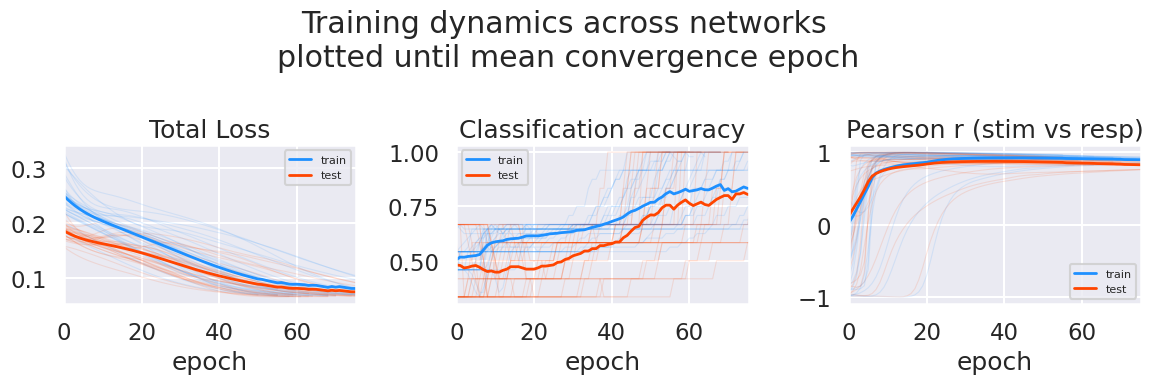

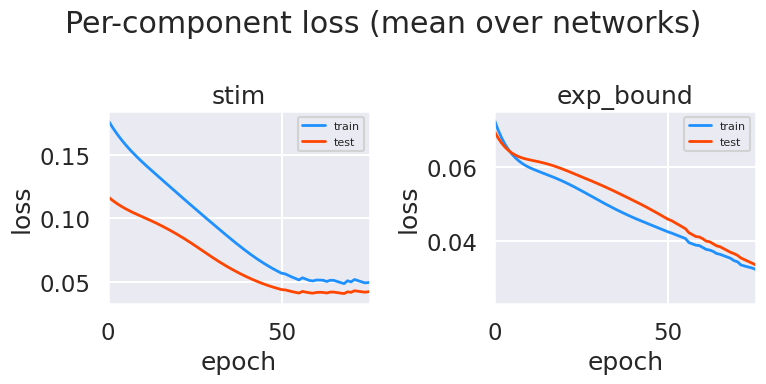

In [9]:
# ── Concatenate all per-epoch records across networks ─────────────────────────
all_epochs = pd.concat(
    [r['epoch_results'] for r in network_results],
    ignore_index=True,
)

# ── 1. Total Loss & Accuracy over epochs (train vs test) ─────────────────────
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs = axs.flatten()

for ax, (title, train_col, test_col) in zip(axs, [
    ('Total Loss',                'train_total',  'test_total'),
    ('Classification accuracy',   'train_acc',    'test_acc'),
    ('Pearson r (stim vs resp)',  'train_corr',   'test_corr'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)

    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=2, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=2, label='test')

    ax.set(title=title, xlabel='epoch', ylabel='', xlim=(0, nets_summarized_df['epochs_ran'].mean()))
    ax.legend(fontsize=8)

plt.suptitle('Training dynamics across networks \nplotted until mean convergence epoch')
plt.tight_layout()
plt.show()

# ── 2. Per-component loss (mean over networks) ───────────────────────────────
loss_comps = ['loss_stim', 'loss_exp_bound']

fig, axs = plt.subplots(1, len(loss_comps), figsize=(4 * len(loss_comps), 4))
axs = axs.flatten()

for ax, comp in zip(axs, loss_comps):
    tr_col, te_col = f'train_{comp}', f'test_{comp}'
    mn = all_epochs.groupby('epoch')[[tr_col, te_col]].mean()
    ax.plot(mn.index, mn[tr_col], color='dodgerblue', linewidth=2, label='train')
    ax.plot(mn.index, mn[te_col], color='orangered',  linewidth=2, label='test')
    ax.set(title=comp.replace('loss_', ''), xlabel='epoch', ylabel='loss', xlim=(0, nets_summarized_df['epochs_ran'].mean()))
    ax.legend(fontsize=8)

plt.suptitle('Per-component loss (mean over networks)')
plt.tight_layout()
plt.show()


### Behavior

response distributions

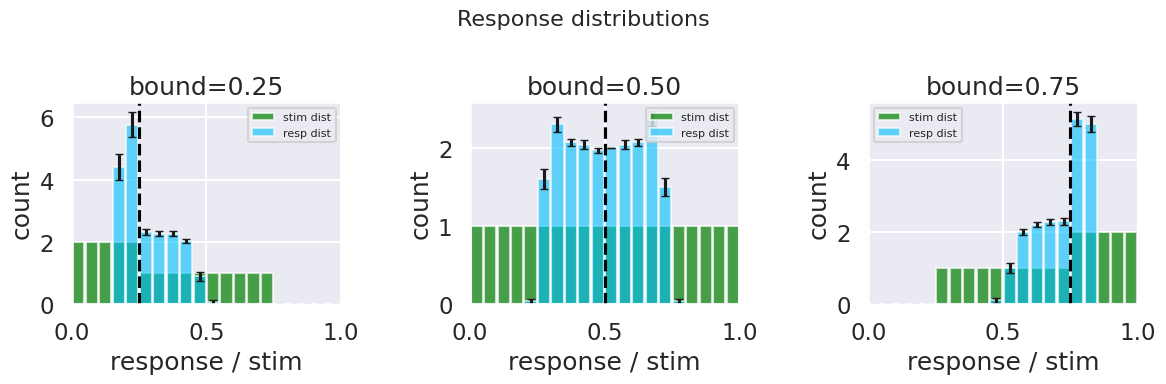

In [10]:
# collect all network predictions on full 60-trial grid
beh_df = pd.concat(
    [network_result['full_pred_df'].assign(net_idx=network_result['net_idx']) for network_result in network_results],
    ignore_index=True,
)

# shared config
b_colors = {0.25: 'orangered', 0.50: 'gray', 0.75: 'dodgerblue'}
n_bins = 20

# ── Plot 1: Response histogram (1×3, per boundary) ───────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs, ax = axs.flatten(), 0

for bound in boundaries:
    cond_df = beh_df[beh_df['boundary'] == bound]

    resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'):
        counts, _ = np.histogram(net_df['resp'], bins=n_bins, range=(0, 1))
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)

    mean_cts = resp_cts.mean(axis=0)
    sem_cts  = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])
    bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

    # true stimulus distribution for this boundary
    stim_vals = trials_df[trials_df['boundary'] == bound]['stim'].values
    stim_cts, _ = np.histogram(stim_vals, bins=n_bins, range=(0, 1))

    # overlay: stim dist in muted color behind, response dist in front
    axs[ax].bar(bin_centers, stim_cts, width=1/n_bins * 0.9,
                color='green', edgecolor='white', alpha=0.7, label='stim dist')
    axs[ax].bar(bin_centers, mean_cts, width=1/n_bins * 0.9,
                color='deepskyblue', alpha=0.6, yerr=sem_cts, capsize=3, label='resp dist')
    axs[ax].axvline(bound, color='black', linestyle='--')
    axs[ax].set(xlabel='response / stim', ylabel='count', title=f'bound={bound:.2f}', xlim=(0, 1))
    axs[ax].legend(fontsize=8)
    ax += 1

plt.suptitle('Response distributions', fontsize=16)
plt.tight_layout()
plt.show()


In [11]:
for b in boundaries:
    print(f'\n=== b={b:.2f} ===')
    for cls in [0, 1]:
        sub = beh_df[(beh_df['boundary'] == b) & (beh_df['class'] == cls)]
        print(f'  class={int(cls)}: mean_stim={sub["stim"].mean():.3f}  mean_resp={sub["resp"].mean():.3f}  '
              f'r={stats.pearsonr(sub["stim"], sub["resp"])[0]:.3f}')


=== b=0.25 ===
  class=0: mean_stim=0.125  mean_resp=0.204  r=0.781
  class=1: mean_stim=0.500  mean_resp=0.358  r=0.962

=== b=0.50 ===
  class=0: mean_stim=0.262  mean_resp=0.376  r=0.987
  class=1: mean_stim=0.738  mean_resp=0.621  r=0.991

=== b=0.75 ===
  class=0: mean_stim=0.500  mean_resp=0.640  r=0.959
  class=1: mean_stim=0.875  mean_resp=0.800  r=0.936


In [12]:
for b in [0.25, 0.75]:
    comp_class = 0 if b == 0.25 else 1
    sub = beh_df[(beh_df['boundary'] == b) & (beh_df['class'] == comp_class)]
    print(f'b={b} compressed class={comp_class}:')
    print(f'  mean stim : {sub["stim"].mean():.3f}')
    print(f'  mean resp : {sub["resp"].mean():.3f}')
    print(f'  centroid  : {b/2 if b==0.25 else (b + 1)/2:.3f}')
    print(f'  boundary  : {b:.3f}')

b=0.25 compressed class=0:
  mean stim : 0.125
  mean resp : 0.204
  centroid  : 0.125
  boundary  : 0.250
b=0.75 compressed class=1:
  mean stim : 0.875
  mean resp : 0.800
  centroid  : 0.875
  boundary  : 0.750


In [13]:
# ── Confusion matrix components by boundary condition ────────────────────────
for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    y_true = sub['class'].values
    y_pred = (sub['resp'].values >= b).astype(float)

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    print(f'b={b:.2f} | TP={tp:4d}  TN={tn:4d}  FP={fp:4d}  FN={fn:4d}  '
          f'acc={( tp + tn) / (tp + tn + fp + fn):.3f}')

b=0.25 | TP= 295  TN= 300  FP=   0  FN=   5  acc=0.992
b=0.50 | TP= 300  TN= 300  FP=   0  FN=   0  acc=1.000
b=0.75 | TP= 300  TN= 296  FP=   4  FN=   0  acc=0.993


stim vs resp

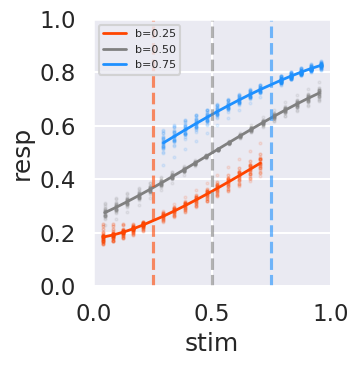

In [14]:
# ── Plot 2: Raw stim vs resp ──────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim'], sub['resp'], 'o',
            markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim')['resp'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2,
            label=f'b={b:.2f}', color=b_colors[b])

for b in boundaries:
    ax.axvline(b, color=b_colors[b], linestyle='--', alpha=0.6)

ax.set(xlabel='stim', ylabel='resp', xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


stim vs resp, boundary-aligned

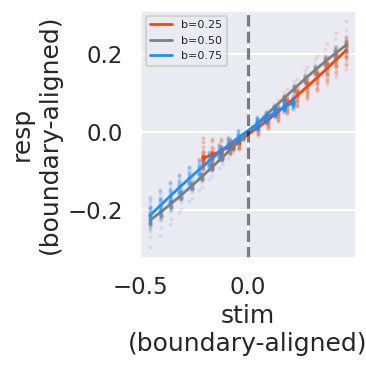

In [15]:
# ── Plot 3: Boundary-aligned stim vs resp ─────────────────────────────────────
beh_df['stim_aligned'] = beh_df['stim'] - beh_df['boundary']
beh_df['resp_aligned'] = beh_df['resp'] - beh_df['boundary']

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim_aligned'], sub['resp_aligned'], 'o',
            markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim_aligned')['resp_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2,
            label=f'b={b:.2f}', color=b_colors[b])

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set(xlabel='stim\n(boundary-aligned)', ylabel='resp\n(boundary-aligned)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


stim vs resp, ranked

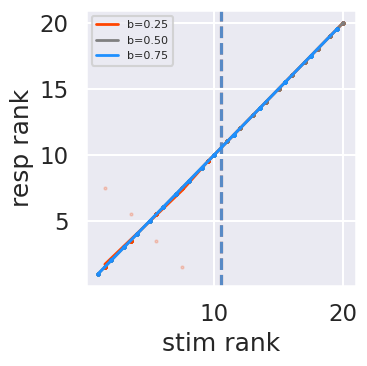

In [16]:
# ── Plot 4: Stim rank vs resp rank ────────────────────────────────────────────
beh_df['stim_rank'] = beh_df.groupby(['net_idx', 'boundary'])['stim'].rank()
beh_df['resp_rank'] = beh_df.groupby(['net_idx', 'boundary'])['resp'].rank()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim_rank'], sub['resp_rank'], 'o',
            markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim_rank')['resp_rank'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2,
            label=f'b={b:.2f}', color=b_colors[b])
    n_below = int((trials_df[trials_df['boundary'] == b]['stim'] < b).sum())
    ax.axvline(n_below + 0.5, color=b_colors[b], linestyle='--', alpha=0.6)

ax.set(xlabel='stim rank', ylabel='resp rank')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Neural

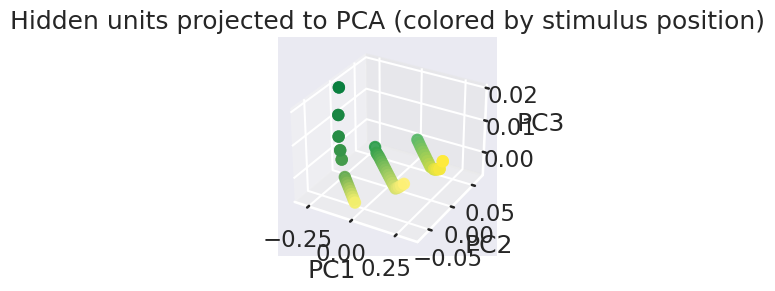

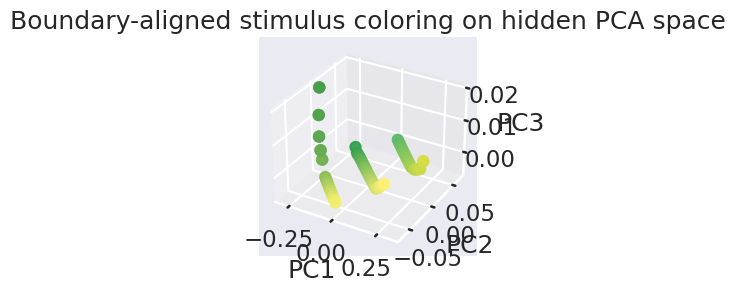

,boundary,bound_pos
0,0.25,0.251894
1,0.50,0.500000
2,0.75,0.748106


In [23]:

# average hidden activations across networks for each of the 60 trials
hidden_stack = np.stack([r['hidden_full'] for r in network_results], axis=0)  # [n_nets, 60, 10]
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# project to 3 PCs
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)

pca_df = trials_df.copy()
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# three green->yellow spectra (one per boundary)
cond_cmaps = {
    0.25: LinearSegmentedColormap.from_list('gy_025', ['#0a7f3f', '#f3ef6d']),
    0.50: LinearSegmentedColormap.from_list('gy_050', ['#2c9e4b', '#fff176']),
    0.75: LinearSegmentedColormap.from_list('gy_075', ['#59b96a', '#ffeb3b']),
}

# plot 1: PCA with color encoding stimulus position within each condition
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    norm = Normalize(vmin=cond_df['stim'].min(), vmax=cond_df['stim'].max())
    colors = cond_cmaps[bound](norm(cond_df['stim'].values))

    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, label=f'b={bound:.2f}')
ax.set_title('Hidden units projected to PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
# ax.legend(loc='best')
plt.tight_layout()
plt.show()

# boundary-align stimulus positions
# bound_pos = midpoint of the two stimuli that flank the boundary (per condition)
bound_pos = {}
for bound in boundaries:
    stim_vals = np.sort(pca_df.loc[pca_df['boundary'] == bound, 'stim'].unique())
    lower = stim_vals[stim_vals < bound].max()
    upper = stim_vals[stim_vals > bound].min()
    bound_pos[bound] = (lower + upper) / 2.0   # midpoint, not distance

# subtract per-condition midpoint so 0 sits at the functional boundary
pca_df['stim_aligned'] = pca_df['stim'] - pca_df['boundary'].map(bound_pos)

shared_norm = Normalize(vmin=pca_df['stim_aligned'].min(), vmax=pca_df['stim_aligned'].max())

# plot 2: boundary-aligned stimulus coloring
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for b in boundaries:
    sub = pca_df[pca_df['boundary'] == b].sort_values('stim_aligned')
    colors = cond_cmaps[b](shared_norm(sub['stim_aligned'].values))
    ax.scatter(sub['PC1'], sub['PC2'], sub['PC3'], c=colors, s=55, alpha=0.9, label=f'b={b:.2f} aligned')

ax.set_title('Boundary-aligned stimulus coloring on hidden PCA space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
# ax.legend(loc='best')
plt.tight_layout()
plt.show()

pd.DataFrame({'boundary': list(bound_pos.keys()), 'bound_pos': list(bound_pos.values())})
